In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [3]:
conn= sqlite3.connect('inventory_db')
df=pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,Actual_price,TotalSalesPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,750.0,36.99,295.92,8,190.88,18.0,665.82,2.00,27.08,474.94,71.331591,2.250000,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,162.5,24.99,449.82,320,5440.00,24.0,599.76,0.52,27.08,-4840.24,-807.029478,0.075000,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,3750.0,134.49,0.00,1,105.07,0.0,0.00,0.00,0.00,-105.07,-inf,0.000000,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,750.0,14.99,494.67,39,446.16,47.0,704.53,37.01,367.52,258.37,36.672675,1.205128,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,1750.0,14.99,0.00,6,66.60,0.0,0.00,0.00,0.00,-66.60,-inf,0.000000,0.000000


In [4]:
df['VendorNumber'].nunique()

126

In [5]:
num_df = df.select_dtypes(include="number")
(num_df == 0).sum()


VendorNumber               0
Brand                      0
PurchasePrice              0
Volume                     0
Actual_price               0
TotalSalesPrice          178
TotalPurchaseQuantity      0
TotalPurchaseDollars       0
TotalSalesQuantity       178
TotalSalesDollars        178
TotalExciseTax           178
FreightCost              178
GrossProfit                1
ProfitMargin               1
StockTurnover            178
SalesToPurchaseRatio     178
dtype: int64

***Exploratory Data Analysis***

* previously, we examined the various table in database to identity key varibles, and understand their relationship, and determines which one should be included in the final analysis.
* Now we analysis the resultant table to gain insights into the distribution of each columns. so we understand the datapatterns, identifly anomalies, and ensure data quality before future analyis.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
Actual_price,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06


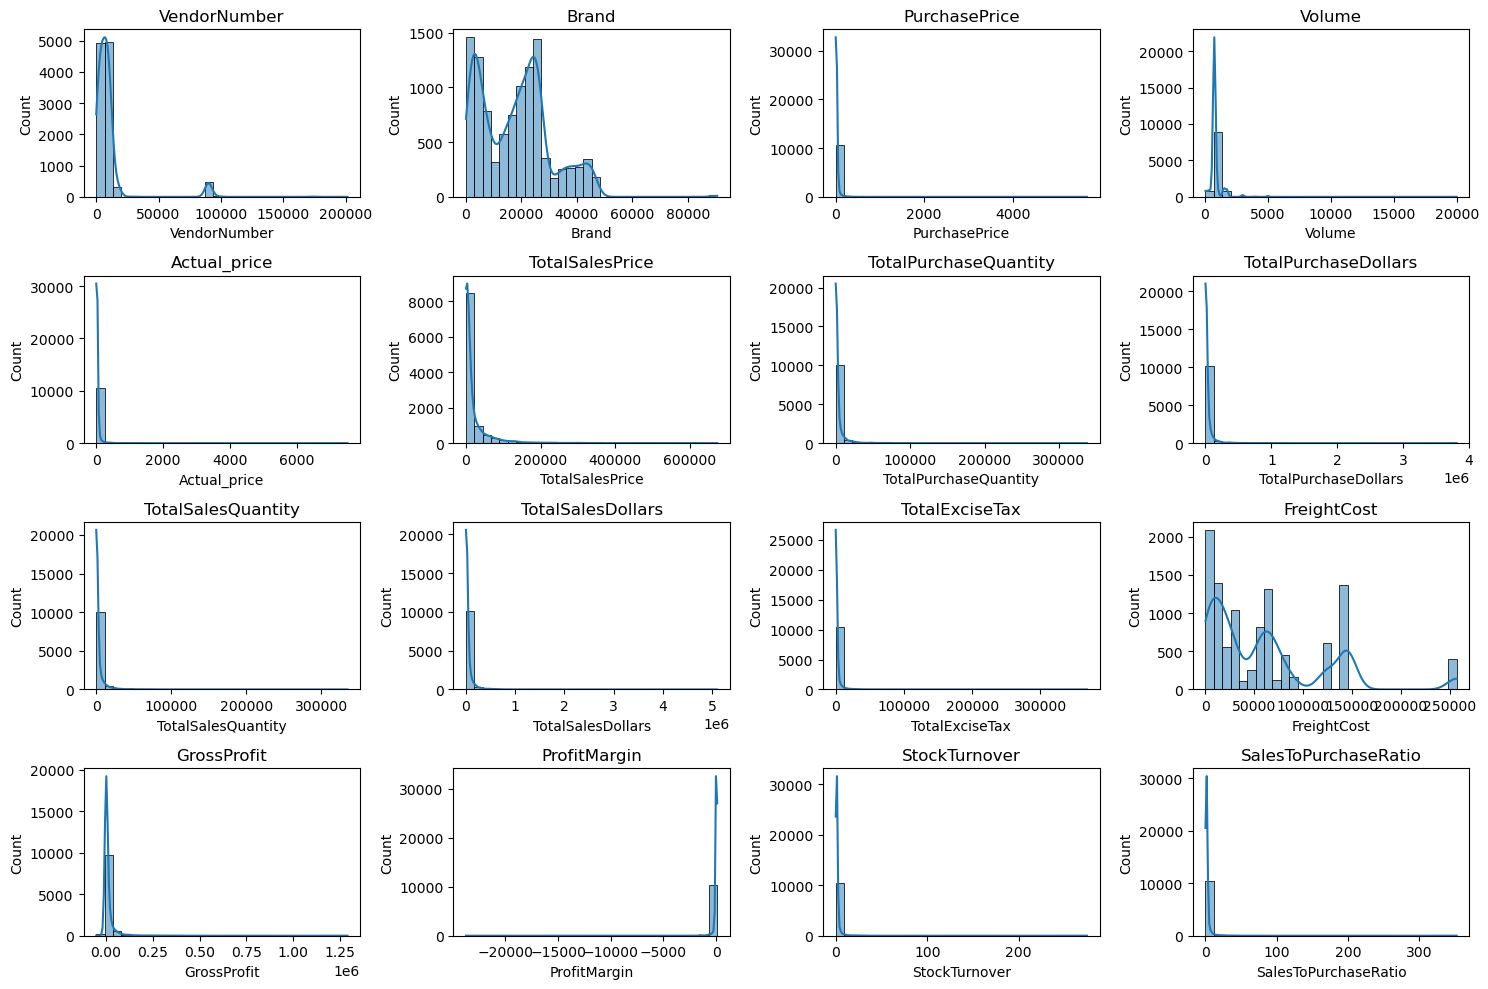

In [7]:
#Distribution plots of numerical columns
numerical_cols= df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i , col in enumerate (numerical_cols):
       plt.subplot(4,4,i+1)
       sns.histplot(df[col],kde=True,bins=30)
       plt.title(col)
plt.tight_layout()
plt.show()
       

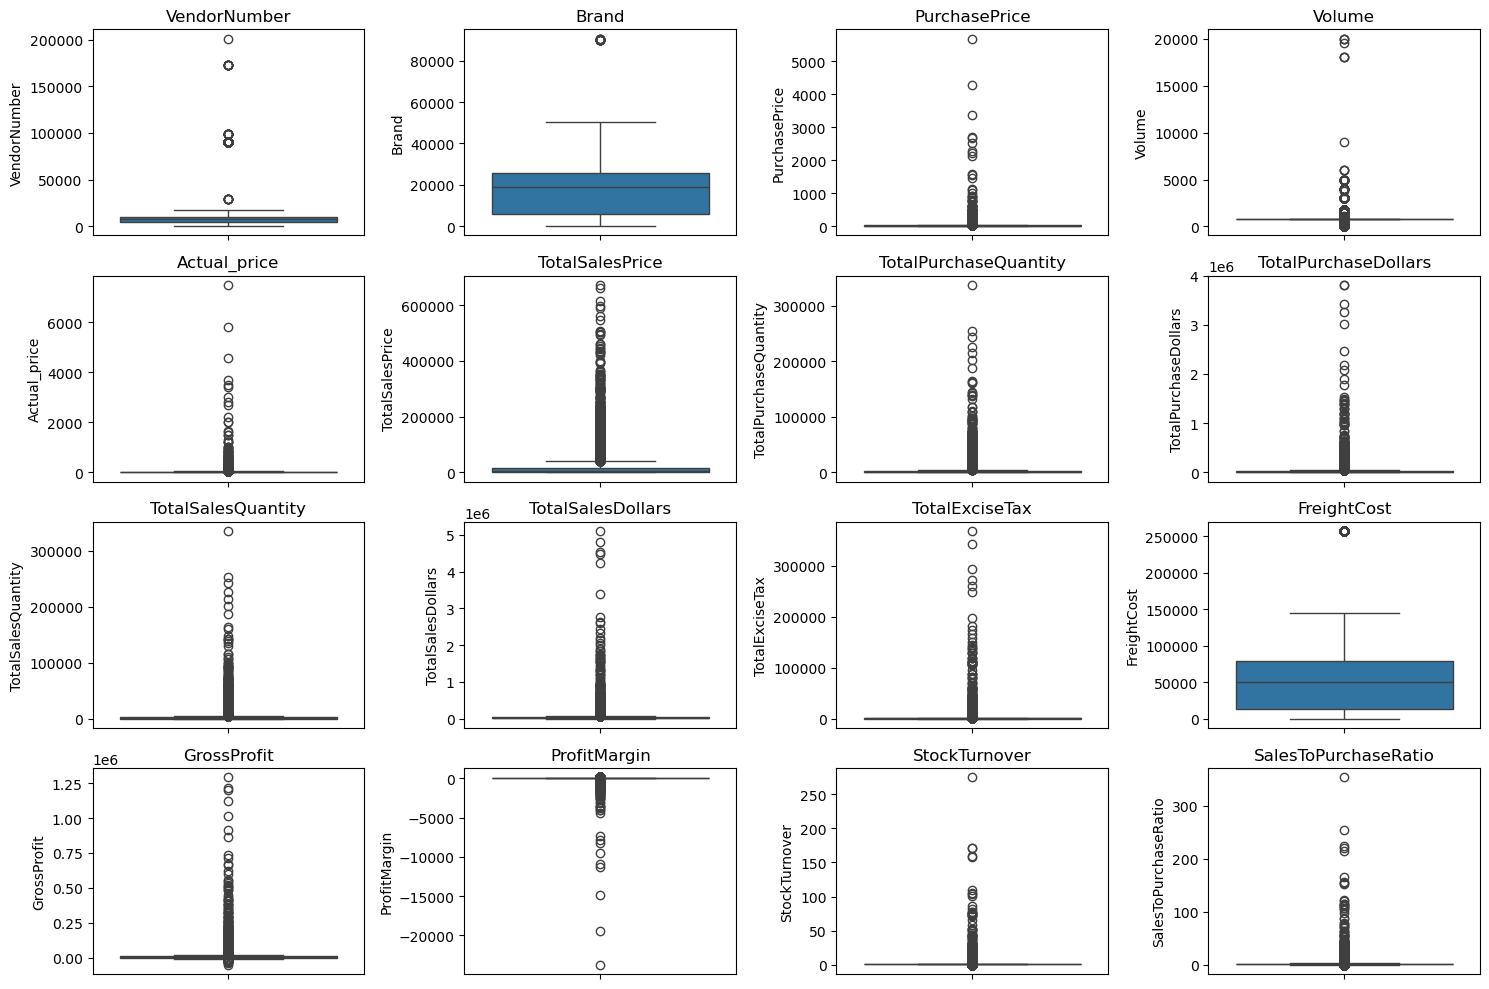

In [8]:
#Outlier detection with boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

#Summery statics insights:
NEGATIVE & ZERO VALUES:
*Gross Profit: min value -522265.34	indicates losses. so some product is selling at loss due to high cost and discount lower than purchase price.
*Profit margin: min -infinity suggest cases where revenue is zero or even lower than costs.
*Total sales quantity and sales dollars: min value is 0 meaning some products are purchsases but never sold.

OUTLIER INDICATED BY HIGH STANDARD DEVIATION:
*purchase & actual prices: max 5681.81,7499.99 significanty higher than mean. indicating premium products.
*freight cost: huge varience 0.27 to 257032.07 suggest logistic inefficiencies or bulk shipments.
*stock_turnover: 0 to 264 indicate some product sell extream fast while other remain in stock indefinitely. vale more than 1 indicates that sold quentity for that prodict is higher than purchases quantity due to either sales are being fulfilled from older stocks.

In [9]:
df= pd.read_sql_query("""select * from vendor_sales_summary where GrossProfit > 0
and ProfitMargin > 0 and TotalsalesQuantity > 0""",conn)
df.shape

(8564, 18)

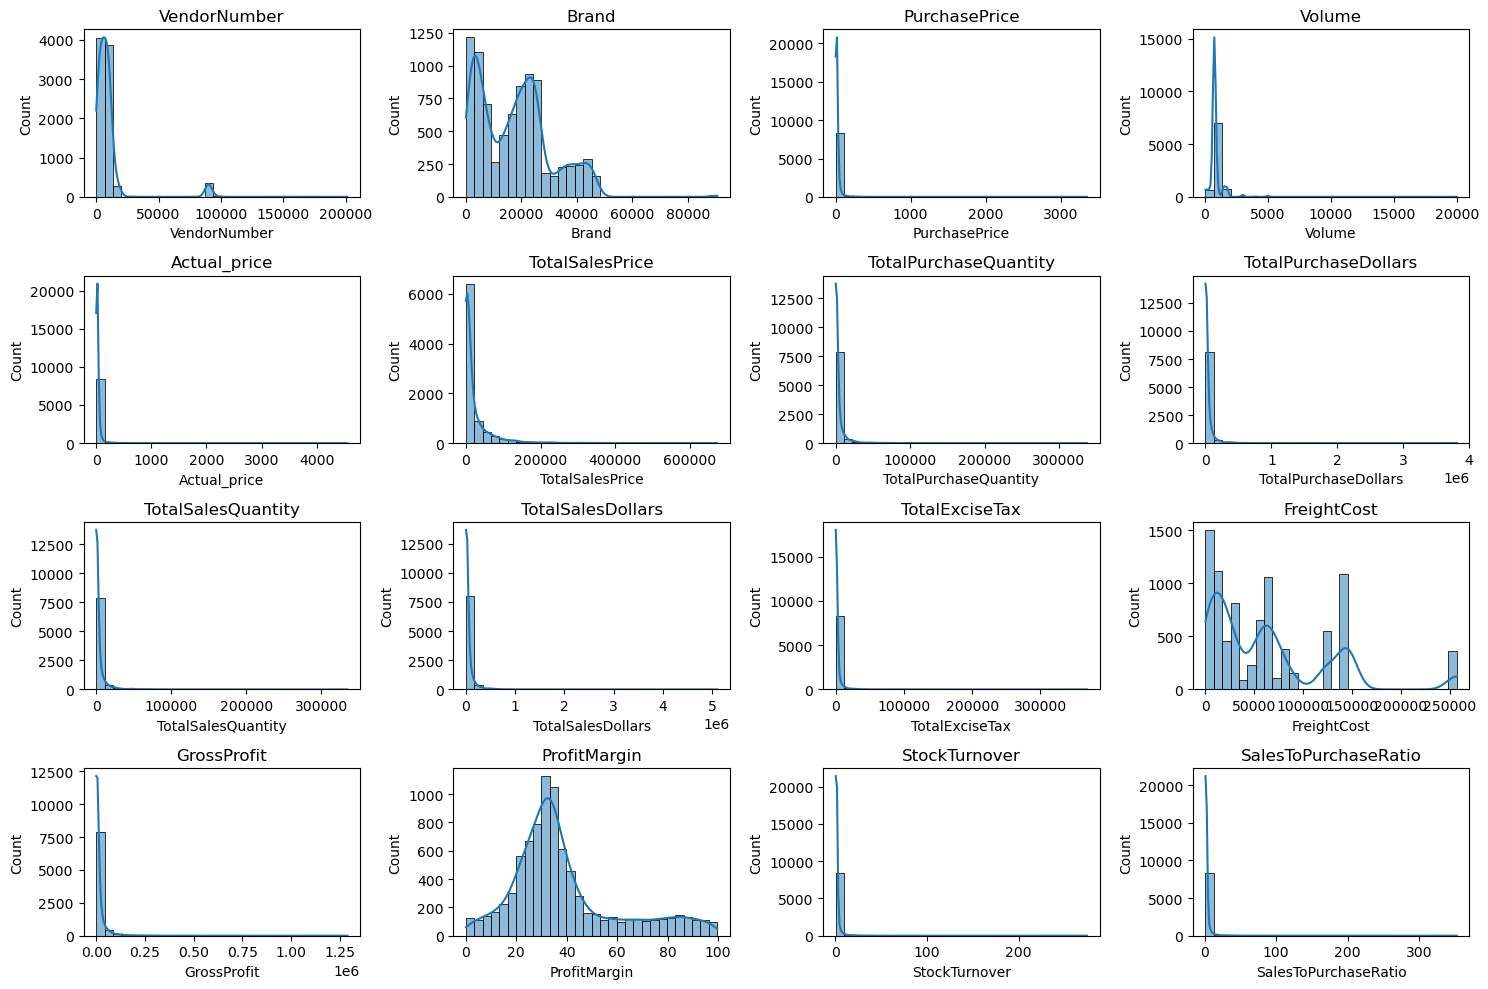

In [10]:
#Distribution plots of numerical columns
numerical_cols= df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i , col in enumerate (numerical_cols):
       plt.subplot(4,4,i+1)
       sns.histplot(df[col],kde=True,bins=30)
       plt.title(col)
plt.tight_layout()
plt.show()
       

In [11]:
df['Description'].nunique()

7707

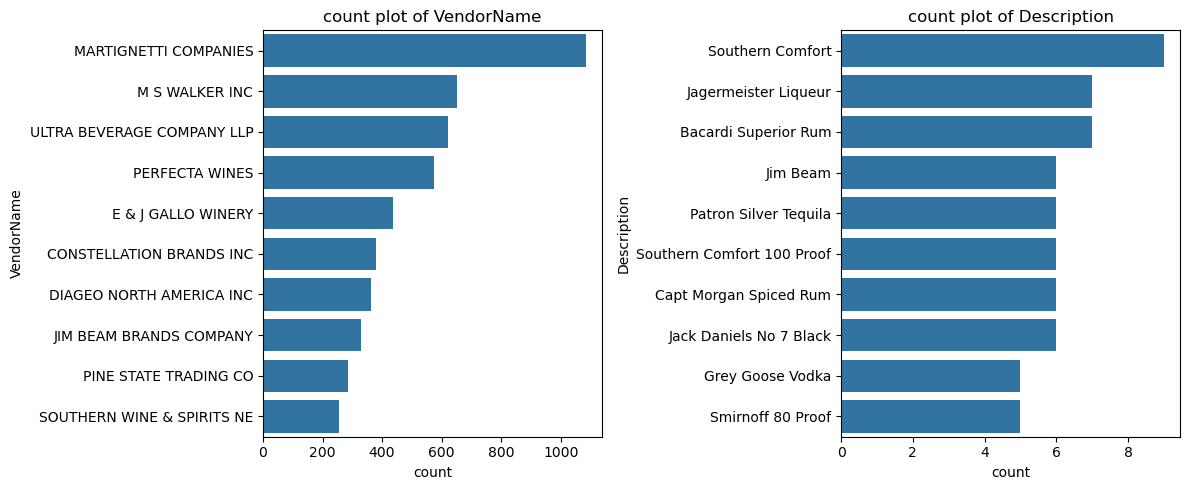

In [12]:
#count plot for categorical columns
categorical_cols= ["VendorName","Description"]
plt.figure(figsize=(12,5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

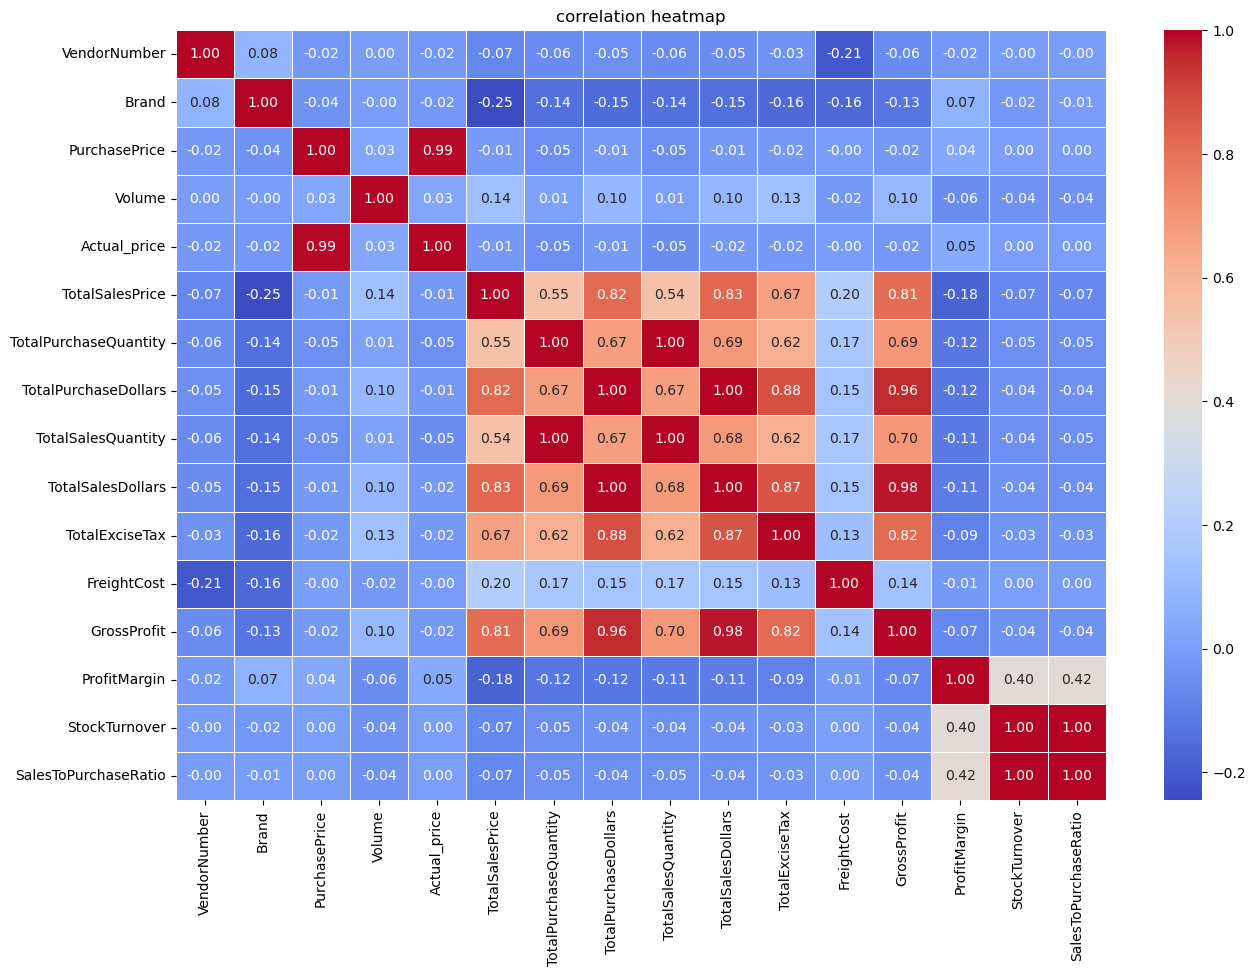

In [13]:
#correlation heatmap
plt.figure(figsize=(15,10))
correlation_matrix= df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.title("correlation heatmap")
plt.show()

* CORRELATION INSIGHTS
* purchase price weak correlation with totalsalesdollars(-0.04)  and gross profit(0) , suggest that price variation do not significantly impact sales revenue or profit.
* strong correlation between purchase quantity and total_sales quantity(0.97),confirming efficient inventory turnover.
* Negative correlation btw profit margin and totalsalesprice (-0.19) show that as sales price increase, margin decrease, possibly due to competative pricing pressure.
* stockturnover has weak correlation with both grossprofit(0.12) and profitmargin(0.38), indicate that faster turnover  may result in higher profitability.

## DATA ANALYSIS

1. Identify brands that need promotional or pricing adjustments which exchibit lower sales performance but higher profit margins ?

In [14]:
brand_performance= df.groupby('Description').agg({'TotalSalesDollars':'sum',
                                                  'ProfitMargin': 'mean'}).reset_index()
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [15]:
df['Description'].value_counts()

Description
Southern Comfort                9
Jagermeister Liqueur            7
Bacardi Superior Rum            7
Jim Beam                        6
Patron Silver Tequila           6
                               ..
Lapierre Raisins 14 Gaulois     1
Guigal Cotes du Rhone Rose      1
Neyers Vyd Chard Carneros       1
Black Ink Red Wine              1
Flavor Essence Variety 5 Pak    1
Name: count, Length: 7707, dtype: int64

In [16]:
low_sales_threshold= brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold= brand_performance['ProfitMargin'].quantile(0.85)

In [17]:
low_sales_threshold

560.299

In [18]:
high_margin_threshold

64.97017552750113

In [19]:
target_brand= brand_performance[(brand_performance['TotalSalesDollars'] <= low_sales_threshold)&
              (brand_performance['ProfitMargin'] >= high_margin_threshold)]
print("brand with low sales but high profit margins:")
display(target_brand.sort_values("TotalSalesDollars"))


brand with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


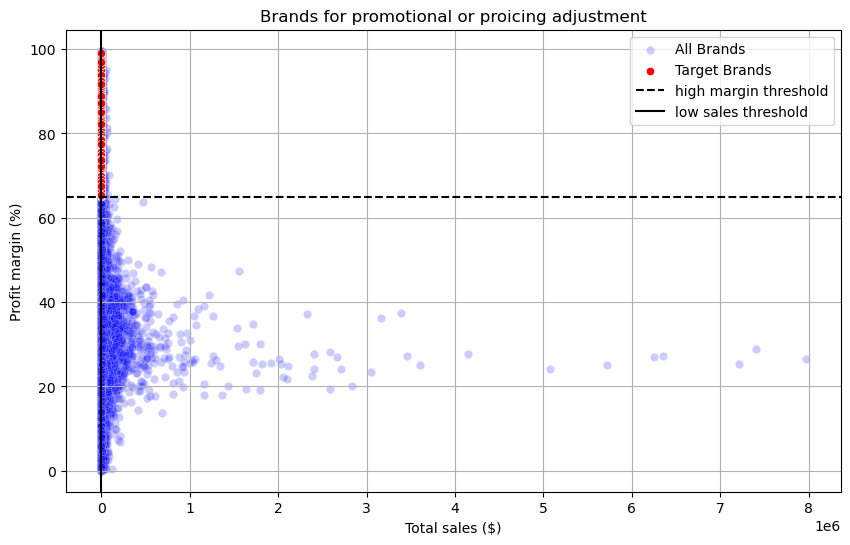

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x="TotalSalesDollars",y="ProfitMargin", color="blue",label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brand, x="TotalSalesDollars",y="ProfitMargin",color= "red",label= "Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color= 'black', label= "high margin threshold")
plt.axvline(low_sales_threshold, linestyle='-', color= 'black' , label= "low sales threshold")

plt.xlabel("Total sales ($)")
plt.ylabel("Profit margin (%)")
plt.title("Brands for promotional or proicing adjustment")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
brand_performance= brand_performance[brand_performance['TotalSalesDollars']<10000]

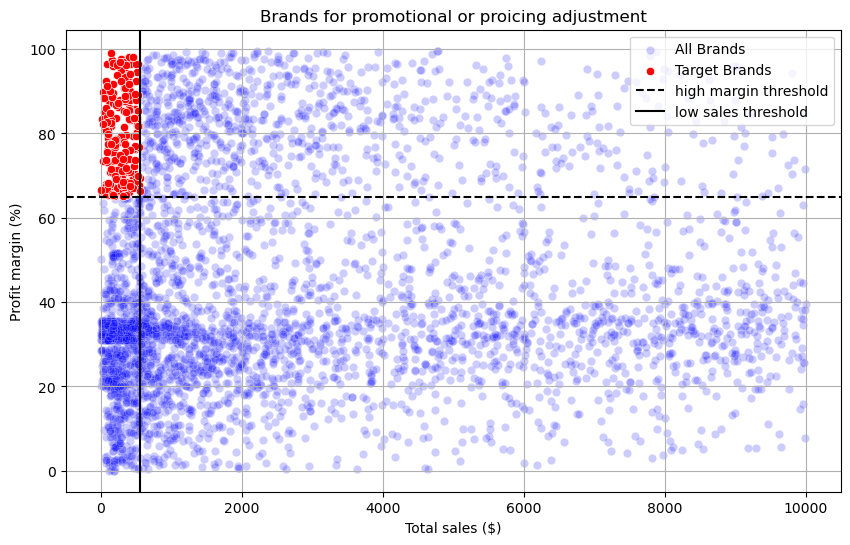

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x="TotalSalesDollars",y="ProfitMargin", color="blue",label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brand, x="TotalSalesDollars",y="ProfitMargin",color= "red",label= "Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color= 'black', label= "high margin threshold")
plt.axvline(low_sales_threshold, linestyle='-', color= 'black' , label= "low sales threshold")

plt.xlabel("Total sales ($)")
plt.ylabel("Profit margin (%)")
plt.title("Brands for promotional or proicing adjustment")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}k"
    else:
        return str(value)

In [26]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

2. Which vendors and brands demonstrate the highest sales pemrformance??

In [25]:
#2. Which vendors and brands demonstrate the highest sales performance??
top_vendors= df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands= df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [27]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

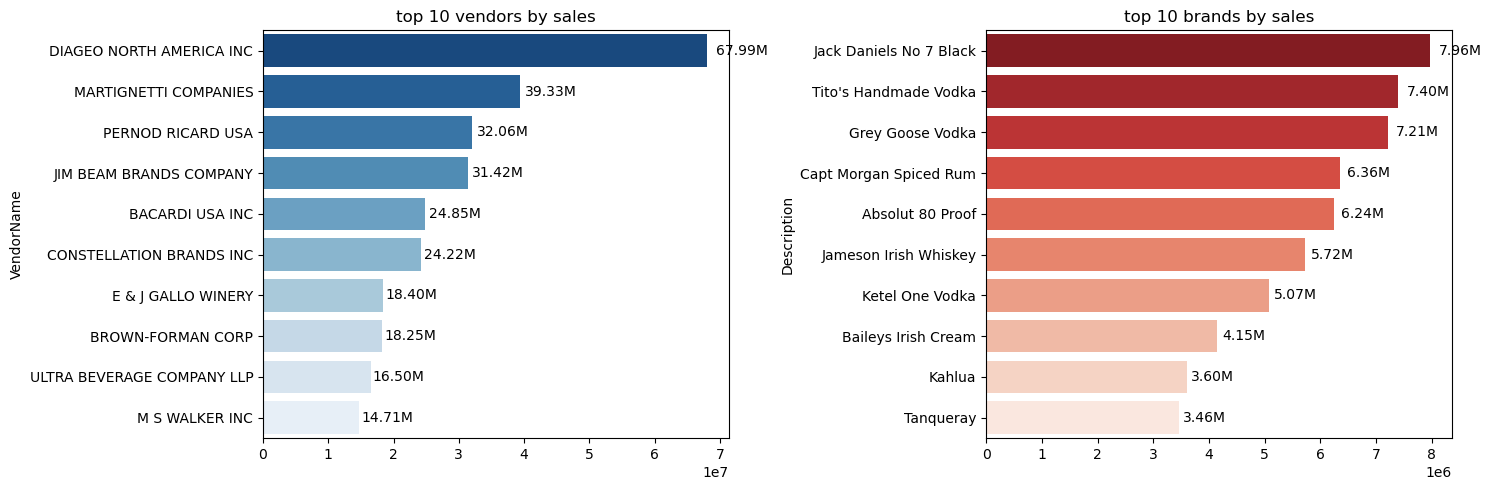

In [28]:
plt.figure(figsize=(15,5))
# plot top vendors

plt.subplot(1,2,1)
ax1= sns.barplot(y=top_vendors.index, x= top_vendors.values, palette= "Blues_r")
plt.title("top 10 vendors by sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() /2 ,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')
            

# plot top brands

plt.subplot(1,2,2)
ax2= sns.barplot(y=top_brands.index, x= top_brands.values, palette= "Reds_r")
plt.title("top 10 brands by sales")

for bar in ax2.patches:
     ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() /2 ,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')


plt.tight_layout()
plt.show()

*3.which vendor contribute the most to total purchase dollars?

In [29]:
df.groupby('VendorName').agg({'TotalPurchaseDollars':'sum',
                              'GrossProfit':'sum',
                              'TotalSalesDollars':'sum'})

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
VendorName,,,
ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...
WEIN BAUER INC,42694.64,13522.49,56217.13
WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20


In [30]:
vendor_performance= df.groupby('VendorName').agg({'TotalPurchaseDollars':'sum',
                              'GrossProfit':'sum',
                              'TotalSalesDollars':'sum'}).reset_index()

In [31]:
vendor_performance.shape

(119, 4)

In [32]:
vendor_performance['PurchaseContribution%']= vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [33]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.000145
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94,0.008362
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,0.003809
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16,0.000304
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53,0.033981
...,...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13,0.013892
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83,0.097097
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20,1.912074
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28,1.693183


In [34]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending= False),2)

In [35]:
# top 10 vendors
top_vendors= vendor_performance.head(10)
top_vendors['TotalSalesDollars']= top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']= top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [36]:
top_vendors['PurchaseContribution%'].sum()

65.69000000000001

In [37]:
top_vendors['Cumulative_Contribution%']= top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


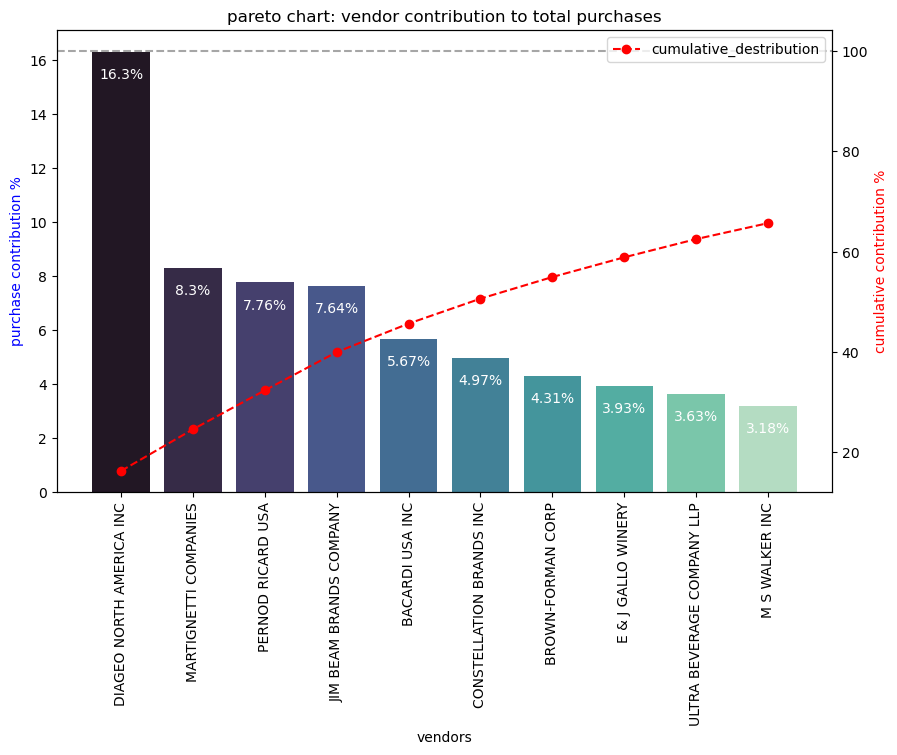

In [38]:
# bar and line plot for top 10 vendors
# barplot for purchase contribution
fig, ax1= plt.subplots(figsize=(10,6))
sns.barplot(x=top_vendors['VendorName'],
            y=top_vendors['PurchaseContribution%'],
            palette='mako',
            ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value-1, str(value)+'%',ha='center',fontsize=10,color='white')

#line plot for cumulative
ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'],top_vendors['Cumulative_Contribution%'],color='red', marker='o',linestyle='dashed',label="cumulative_destribution")

ax1.set_xticklabels(top_vendors['VendorName'],rotation=90)
ax1.set_ylabel('purchase contribution %',color= 'blue')
ax2.set_ylabel("cumulative contribution %",color='red')
ax1.set_xlabel('vendors')
ax1.set_title('pareto chart: vendor contribution to total purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

4.How much of total procurement is dependent on the top vendors?

In [39]:
print(f"Total purchase Countribution of top 10 vendors is { round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total purchase Countribution of top 10 vendors is 65.69%


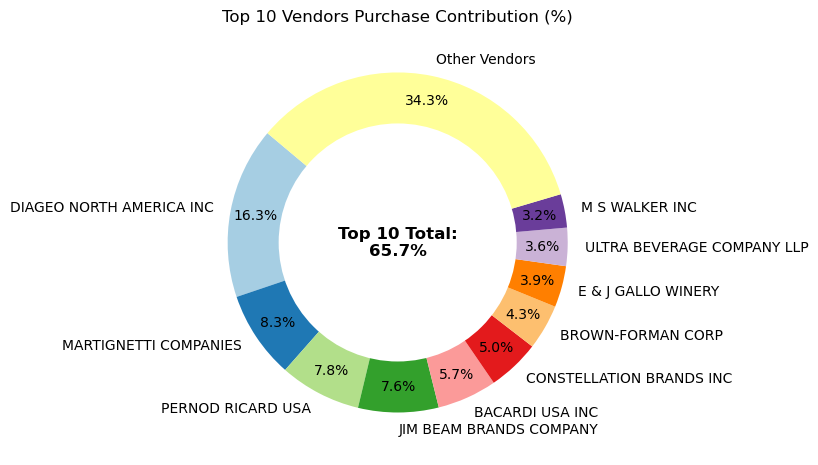

In [40]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(purchase_contributions,labels=vendors,autopct='%1.1f%%',
                                  startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.text(0, 0,f"Top 10 Total:\n{total_contribution:.1f}%",ha='center',va='center',
              fontsize=12,fontweight='bold'
)

plt.title("Top 10 Vendors Purchase Contribution (%)")
plt.tight_layout()
plt.show()

5. does purchasing in bulk reduce the unit price , and what is the optiomal purchase volume for cost saving?

In [41]:
df['UnitPurchasePrice']= df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [42]:
df['OrderSize']= pd.qcut(df['TotalPurchaseQuantity'],q=3, labels=["Small","medium","large"])

In [43]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
medium,15.486414
large,10.777625


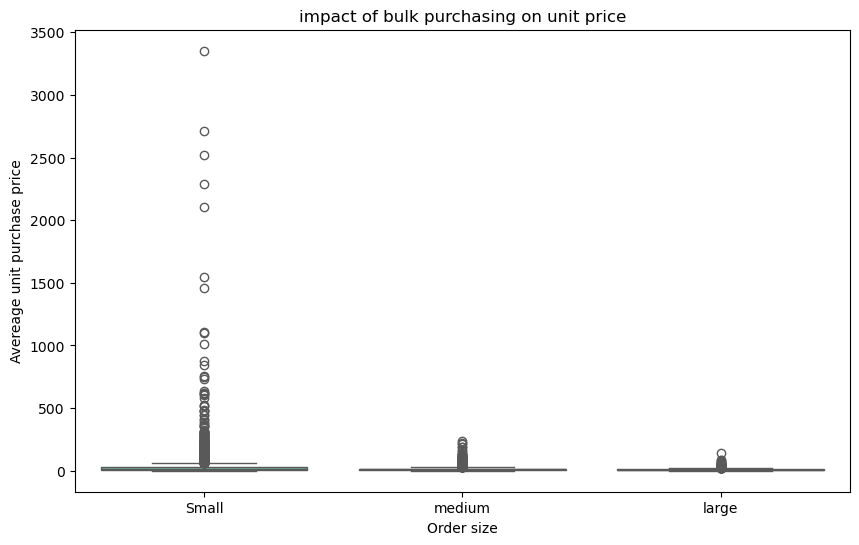

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize",y="UnitPurchasePrice", palette= "Set2")
plt.title("impact of bulk purchasing on unit price")
plt.xlabel("Order size")
plt.ylabel("Avereage unit purchase price")
plt.show()

* vendors buying in bulk get lower unit price(10.777625) meaning higher margins if they can manage inventory efficiently.
* there is significant diff btw small and large sunstantial.
* this suggest that bulk pricing stratigies encourage vendoe to purchase larger volume.

6. which vendor have low inventory turnover, indicating excess stock and slow-moving products?`

In [46]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending= True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


7. How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [49]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
print("Total Unsold Capital:", format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: 2.71M


In [51]:
inventory_value_per_vendor= df.groupby("VendorName")['UnsoldInventoryValue'].sum().reset_index()
inventory_value_per_vendor= inventory_value_per_vendor.sort_values(by='UnsoldInventoryValue',ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21k
46,JIM BEAM BRANDS COMPANY,554.67k
68,PERNOD RICARD USA,470.63k
116,WILLIAM GRANT & SONS INC,401.96k
30,E & J GALLO WINERY,228.28k
79,SAZERAC CO INC,198.44k
11,BROWN-FORMAN CORP,177.73k
20,CONSTELLATION BRANDS INC,133.62k
61,MOET HENNESSY USA INC,126.48k
77,REMY COINTREAU USA INC,118.60k


8. what is 95% confidence intervals for profit margins of top-performing an low-performing vendors.

In [52]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# top 25%
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
# bottom 25%
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()
low_vendors

0       71.331591
1       36.672675
2       22.474158
9       20.559532
10      64.915236
          ...    
8549    41.388657
8550    21.862972
8551    73.338465
8553    40.470235
8556    88.098999
Name: ProfitMargin, Length: 2141, dtype: float64

In [53]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


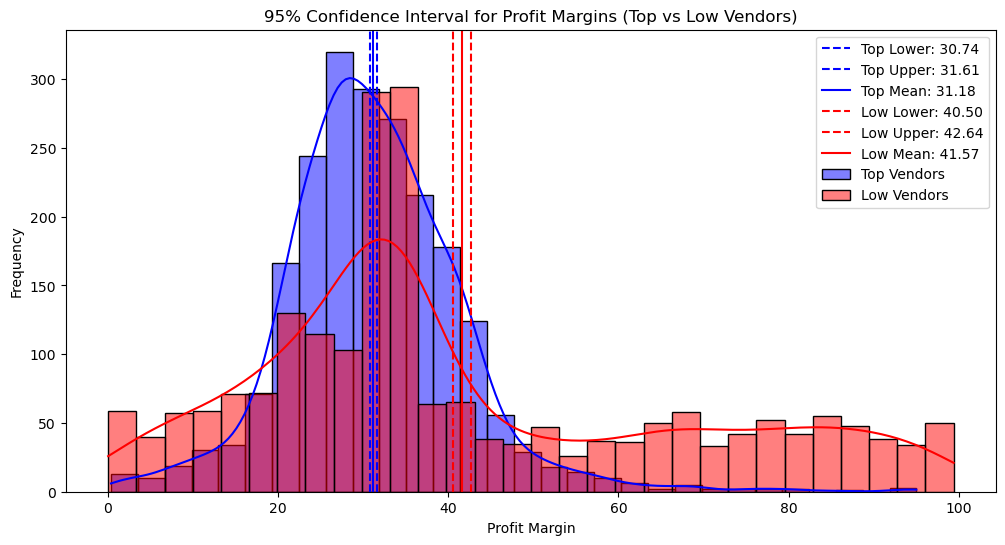

In [54]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")


plt.figure(figsize=(12, 6))
#low vendor plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")
#top vendor plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")
#finalize plot
plt.title("95% Confidence Interval for Profit Margins (Top vs Low Vendors)")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
'''Low-performing vendors have higher profit margins (40–42%) than top-performing vendors (30–31%).
This means low-sales vendors keep higher margins, while high-sales vendors focus on volume with lower margins.
Top vendors can improve profit by optimizing costs or adjusting prices.
Low vendors should improve marketing and pricing to increase sales.'''

9. Hypothesis:
H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [56]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
